# Event Simulation

This notebook validates the propagation model against three real historical market events.

**Events Analysed:**
1. AI / Semiconductor Rally (July 2024)
2. Yen Carry-Trade Unwind (August 2024)
3. U.S. Tariff Shock (April 2025)

For each event, actual returns seed the contagion model and predictions are compared against realised post-event performance using Pearson $r$ and $R^2$.


In [1]:
# Setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.data_fetcher import load_metadata, download_prices, compute_log_returns
from src.market_filtering import filter_market_mode
from src.network_construction import build_correlation_graph, SECTOR_COLORS
from src.event_simulation import (
    REAL_EVENTS, simulate_real_event, extract_event_returns,
    extract_observation_returns
)

In [2]:
# Load data & build filtered graph
meta_df = load_metadata(os.path.join('..', 'data', 'sp500_companies.csv'))
prices = download_prices(meta_df['yf_ticker'].tolist(), period='2y',
                         cache_path=os.path.join('..', 'data', 'price_cache.csv'))
log_returns = compute_log_returns(prices)
filtered_corr = filter_market_mode(log_returns).corr()
G = build_correlation_graph(filtered_corr, meta_df, threshold=0.3)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Log-returns: {log_returns.shape[0]} days × {log_returns.shape[1]} stocks")

  ↻ Loading cached prices from ../data/price_cache.csv
Graph: 501 nodes, 10002 edges
Log-returns: 501 days × 501 stocks


## 4.1 Event Definitions


In [3]:
for key, cfg in REAL_EVENTS.items():
    print(f"  {cfg['name']}")
    print(f"  Dates:       {cfg['event_dates']}")
    print(f"  Window:      {cfg.get('observation_window', 5)} trading days")
    print(f"  Description: {cfg['description']}")


  Yen Carry-Trade Unwind (Aug 5, 2024)
  Dates:       ['2024-08-05']
  Window:      3 trading days
  Description: Global equity selloff triggered by BOJ rate hike. Nikkei fell 12.4%, US markets opened sharply lower.

  Trump Tariff Shock — Liberation Day (Apr 2–3, 2025)
  Dates:       ['2025-04-02', '2025-04-03']
  Window:      5 trading days
  Description: Sweeping reciprocal tariffs announced Apr 2, 2025. S&P 500 lost ~12% over the following week.

  AI/Semiconductor Rally (Jul 10–11, 2024)
  Dates:       ['2024-07-10', '2024-07-11']
  Window:      3 trading days
  Description: NVDA, AVGO, AMD surged on AI demand forecasts. Broad tech rally with sector rotation.


## 4.2 Simulate Each Event

For each event:
1. Extract **actual** returns on event day(s)
2. Select top-10 most-moved stocks as contagion sources
3. Run propagation with actual returns as magnitudes
4. Compare model predictions vs **actual post-event returns** (observation window)
5. Compute **Pearson r and R²**

In [4]:
all_results = {}

for event_key, event_config in REAL_EVENTS.items():
    print(f"\n{'='*64}")
    print(f"  {event_key}: {event_config['name']}")
    print(f"{'='*64}")

    result = simulate_real_event(G, log_returns, event_config,
                                 n_sources=10, decay=0.5, max_hops=3)
    if result is None:
        print("  ⚠ No data available, skipping")
        continue

    all_results[event_key] = result
    df = result['results_df']

    print(f"  Validation: r = {result['validation_corr']:.4f}, R² = {result['validation_r2']:.4f}")
    print(f"  Stocks in network: {result['n_stocks']}")
    print(f"  Top movers: {result['top_movers'][:5]}")
    print(f"\n  Top-10 model-predicted impacts:")
    for rank, (sym, row) in enumerate(df.head(10).iterrows(), 1):
        sign = '+' if row['model_predicted'] > 0 else ''
        actual_str = f"actual={row['actual_post_event']:.4f}" if not np.isnan(row['actual_post_event']) else 'actual=N/A'
        print(f"    {rank:>2}. {sym:<8} model={sign}{row['model_predicted']:.4f}  {actual_str}  sector={row['sector']}")


  Yen_Carry_Trade_Unwind: Yen Carry-Trade Unwind (Aug 5, 2024)
  Validation: r = -0.1207, R² = 0.0146
  Stocks in network: 501
  Top movers: ['HOOD', 'COIN', 'SATS', 'LITE', 'INTC']

  Top-10 model-predicted impacts:
     1. HOOD     model=-0.0894  actual=0.0768  sector=Financials
     2. COIN     model=-0.0792  actual=0.0149  sector=Financials
     3. SATS     model=-0.0756  actual=0.1049  sector=Communication Services
     4. LITE     model=-0.0678  actual=0.0441  sector=Information Technology
     5. NVDA     model=-0.0676  actual=0.0440  sector=Information Technology
     6. UAL      model=-0.0662  actual=0.0835  sector=Industrials
     7. INTC     model=-0.0659  actual=0.0250  sector=Information Technology
     8. LUV      model=-0.0560  actual=0.0622  sector=Industrials
     9. XYZ      model=-0.0555  actual=0.0676  sector=Financials
    10. AES      model=-0.0503  actual=0.0219  sector=Utilities

  Tariff_Shock_2025: Trump Tariff Shock — Liberation Day (Apr 2–3, 2025)
  Validat

## 4.3 Model Validation


In [5]:
print(f"Model Validation Summary")
print(f"")
print(f"{'Event':<35} {'r':>8} {'R²':>8}")
for event_key, result in all_results.items():
    name = REAL_EVENTS[event_key]['name']
    print(f"{name:<35} {result['validation_corr']:>8.4f} {result['validation_r2']:>8.4f}")


Model Validation Summary                Event                                      r       R²     Yen Carry-Trade Unwind (Aug 5, 2024)  -0.1207   0.0146     Trump Tariff Shock — Liberation Day (Apr 2–3, 2025)  -0.0116   0.0001     AI/Semiconductor Rally (Jul 10–11, 2024)   0.1530   0.0234     

### Validation Scatter Plots


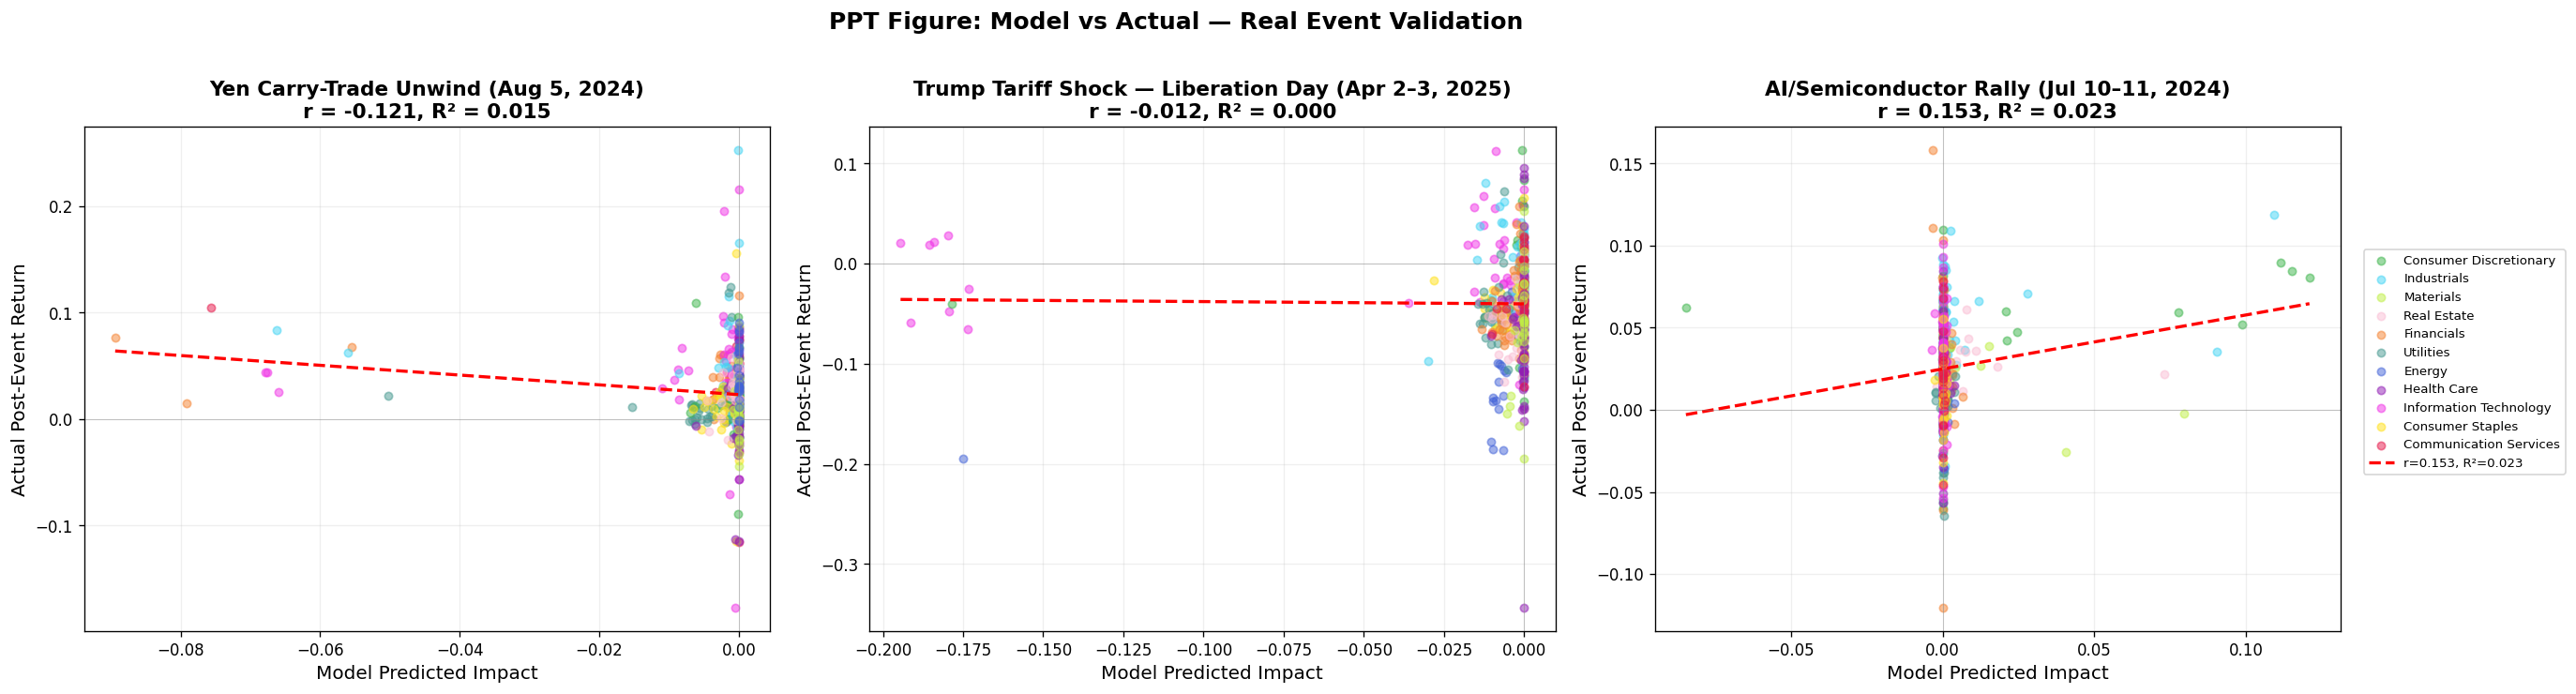

In [6]:
n_events = len(all_results)
fig, axes = plt.subplots(1, n_events, figsize=(7 * n_events, 6))
if n_events == 1:
    axes = [axes]

for ax, (event_key, result) in zip(axes, all_results.items()):
    df = result['results_df'].dropna(subset=['actual_post_event'])
    name = REAL_EVENTS[event_key]['name']
    r = result['validation_corr']
    r2 = result['validation_r2']

    # Scatter by sector
    for sector in df['sector'].unique():
        mask = df['sector'] == sector
        color = SECTOR_COLORS.get(sector, '#999999')
        ax.scatter(df.loc[mask, 'model_predicted'], df.loc[mask, 'actual_post_event'],
                   alpha=0.5, s=25, color=color, label=sector)

    # Regression line
    x = df['model_predicted'].values
    y = df['actual_post_event'].values
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() > 2:
        slope, intercept, _, _, _ = stats.linregress(x[valid], y[valid])
        x_line = np.linspace(x[valid].min(), x[valid].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, '--', color='red', lw=2,
                label=f'r={r:.3f}, R²={r2:.3f}')

    ax.set_xlabel('Model Predicted Impact', fontsize=12)
    ax.set_ylabel('Actual Post-Event Return', fontsize=12)
    ax.set_title(f'{name}\nr = {r:.3f}, R² = {r2:.3f}', fontsize=13, fontweight='bold')
    ax.axhline(0, color='gray', ls='-', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', ls='-', lw=0.5, alpha=0.5)
    ax.grid(alpha=0.2)

# Shared legend
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles[:12], labels[:12], loc='center left', bbox_to_anchor=(1.0, 0.5),
           fontsize=8, ncol=1)

fig.suptitle('Model vs Actual — Real Event Validation',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

### Event-Day Impact


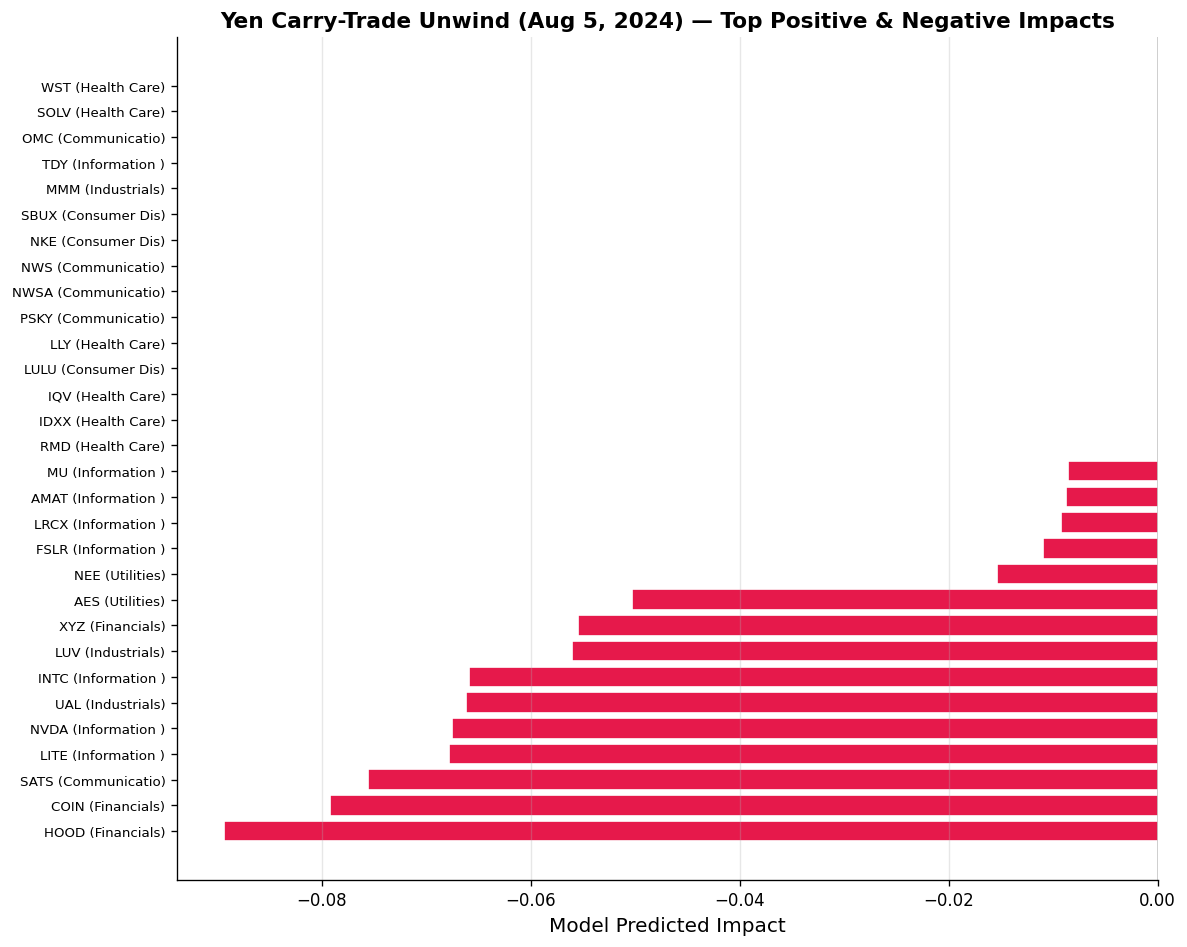

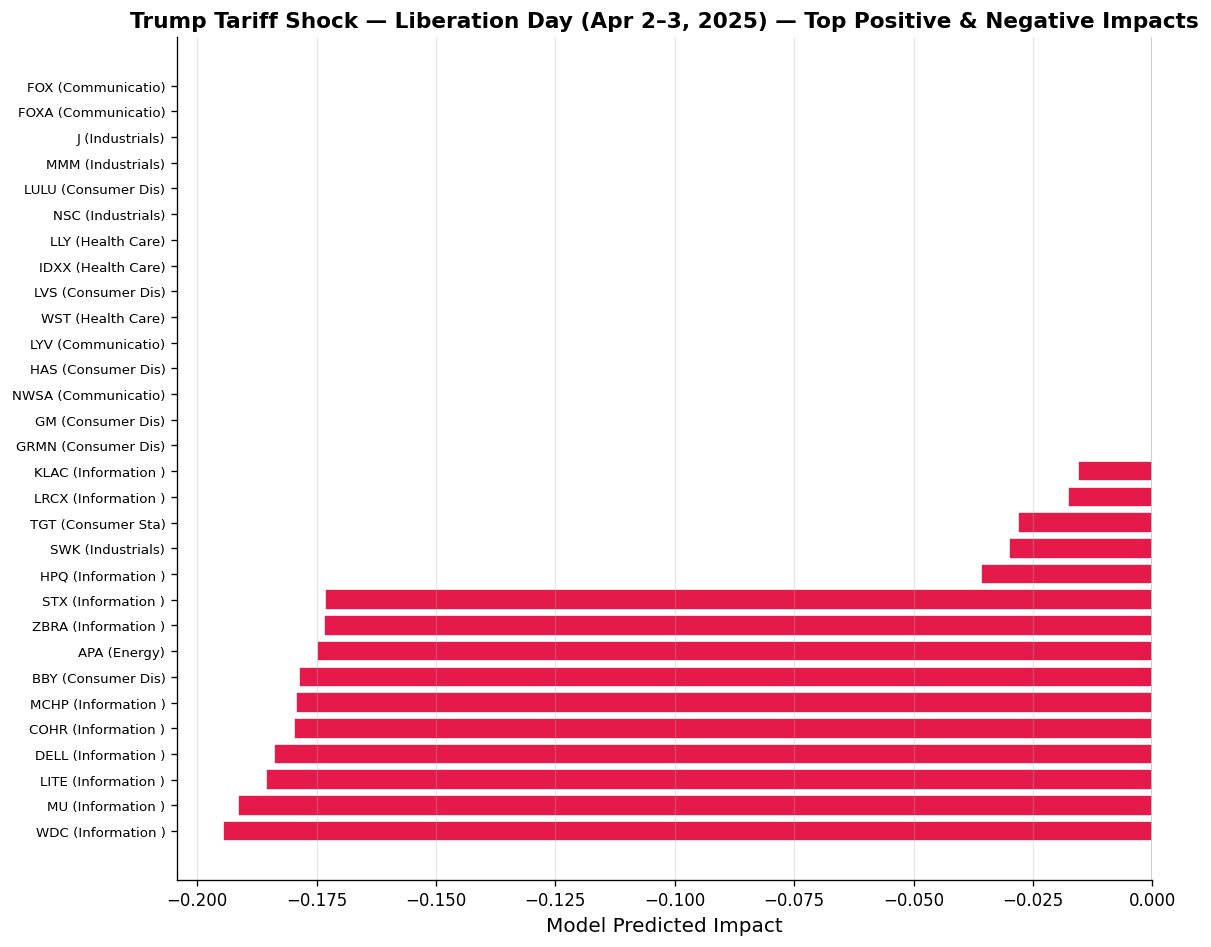

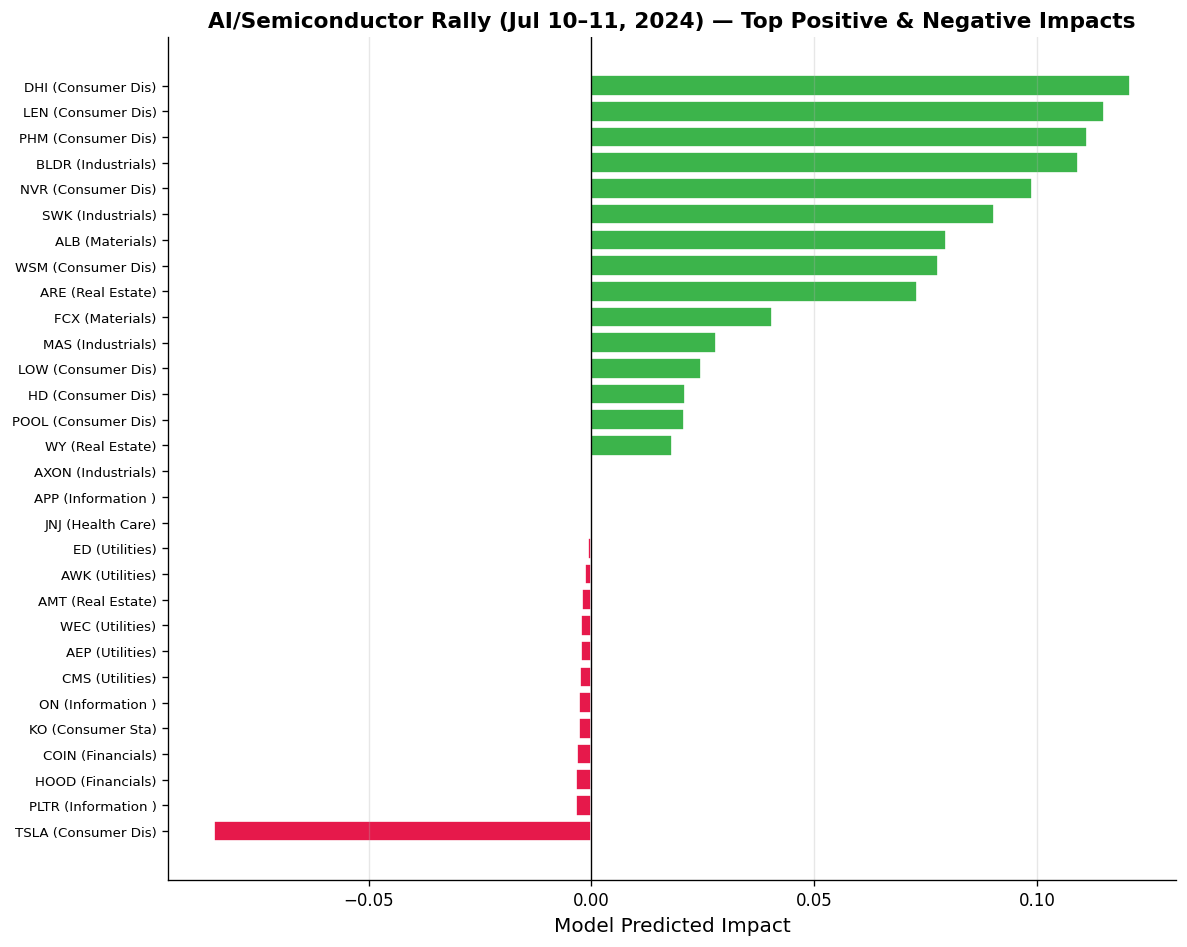

In [7]:
for event_key, result in all_results.items():
    df = result['results_df'].copy()
    name = REAL_EVENTS[event_key]['name']

    # Top 15 positively + top 15 negatively impacted
    top_pos = df.nlargest(15, 'model_predicted')
    top_neg = df.nsmallest(15, 'model_predicted')
    plot_df = pd.concat([top_pos, top_neg]).sort_values('model_predicted')

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#e6194b' if v < 0 else '#3cb44b' for v in plot_df['model_predicted']]
    ax.barh(range(len(plot_df)), plot_df['model_predicted'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels([f"{idx} ({row['sector'][:12]})" for idx, row in plot_df.iterrows()], fontsize=8)
    ax.set_xlabel('Model Predicted Impact', fontsize=12)
    ax.set_title(f'{name} — Top Positive & Negative Impacts', fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', lw=0.8)
    ax.grid(axis='x', alpha=0.3)
    sns.despine()
    fig.tight_layout()
    plt.show()

### Sector-Level Returns


/tmp/ipykernel_61765/2783280397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sector', y='event_day_return', order=sectors_order,
/tmp/ipykernel_61765/2783280397.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


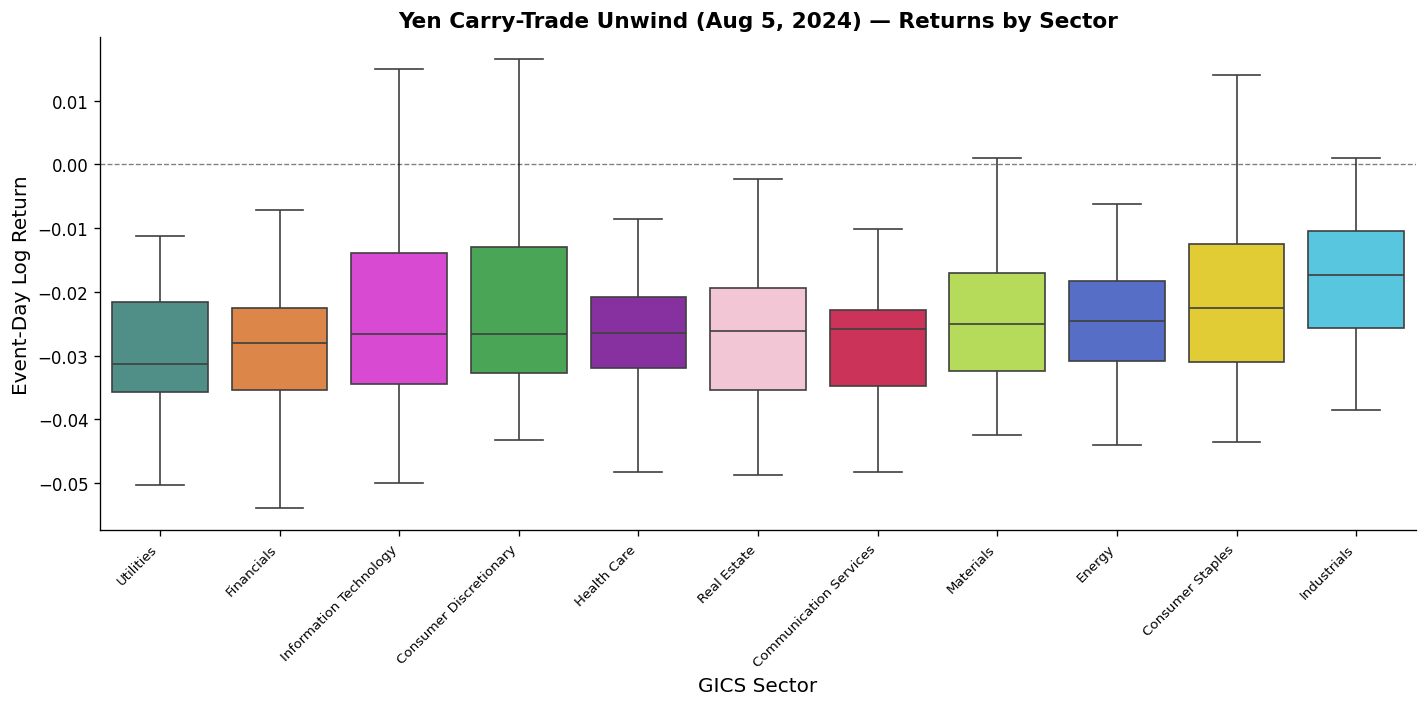

/tmp/ipykernel_61765/2783280397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sector', y='event_day_return', order=sectors_order,
/tmp/ipykernel_61765/2783280397.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


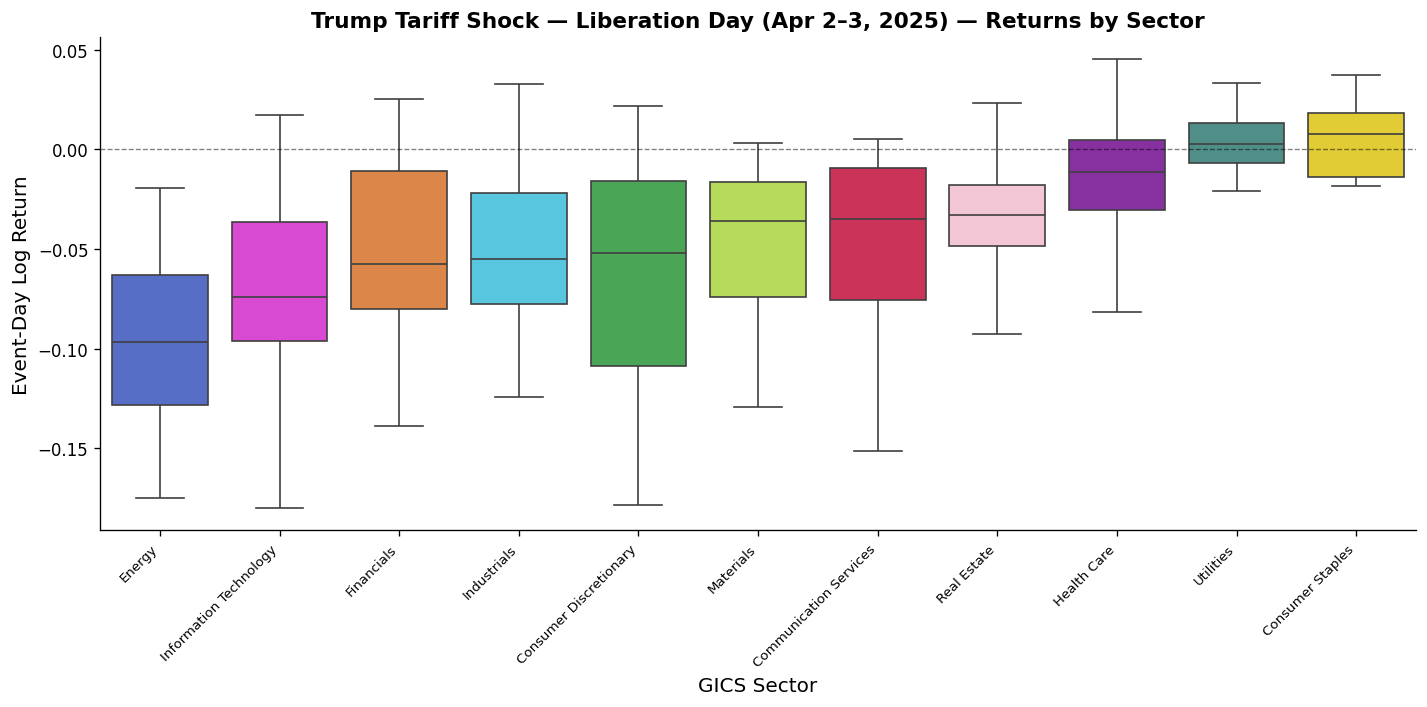

/tmp/ipykernel_61765/2783280397.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sector', y='event_day_return', order=sectors_order,
/tmp/ipykernel_61765/2783280397.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


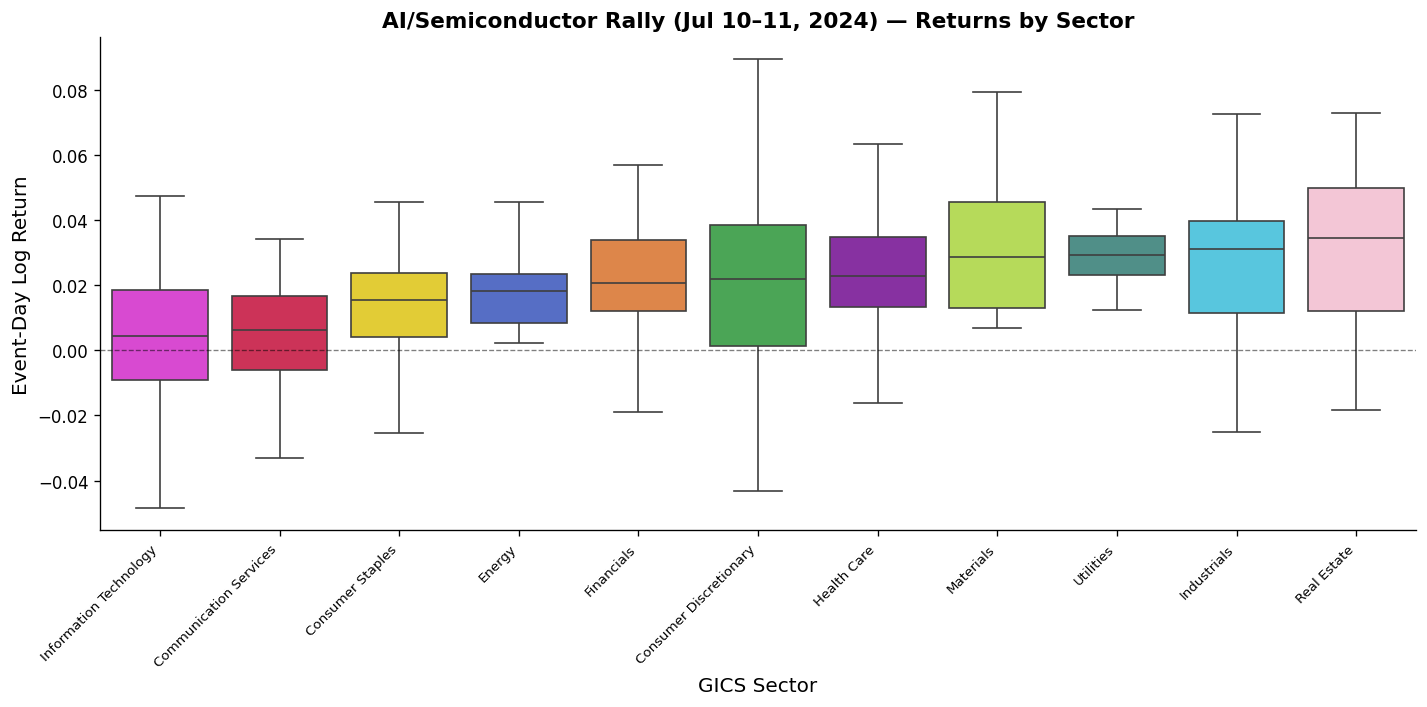

In [8]:
for event_key, result in all_results.items():
    df = result['results_df'].copy()
    name = REAL_EVENTS[event_key]['name']

    fig, ax = plt.subplots(figsize=(12, 6))
    sectors_order = df.groupby('sector')['event_day_return'].median().sort_values().index
    palette = {s: SECTOR_COLORS.get(s, '#999') for s in sectors_order}

    sns.boxplot(data=df, x='sector', y='event_day_return', order=sectors_order,
                palette=palette, ax=ax, showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('GICS Sector', fontsize=12)
    ax.set_ylabel('Event-Day Log Return', fontsize=12)
    ax.set_title(f'{name} — Returns by Sector', fontsize=13, fontweight='bold')
    sns.despine()
    fig.tight_layout()
    plt.show()